# Analisis Dataset ClarkNet-HTTP (Granularitas Detik)
Notebook ini memproses log akses ASCII **ClarkNet-HTTP** (sampel 1 minggu), mem-parsing data waktu, mengelompokkan request ke virtual microservices, dan melakukan agregasi ke **Requests Per Second (RPS)** tingkat detik.

Dataset ini merepresentasikan beban kerja internet service provider (ISP) regional pada tahun 1995.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/clarknet_access_log_Aug28'

print("Membaca dan mem-parsing log file ClarkNet-HTTP secara efisien...")
start_time = time.time()
data = []

with open(log_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        try:
            parts = line.split('"')
            ts_start = parts[0].find('[') + 1
            ts_end = parts[0].find(']')
            # Format: 28/Aug/1995:00:00:34 -0400
            ts_str = parts[0][ts_start:ts_end-6]
            dt = datetime.strptime(ts_str, '%d/%b/%Y:%H:%M:%S')
            
            req_parts = parts[1].split()
            method = req_parts[0]
            filename = req_parts[1]
            
            status_size_parts = parts[2].strip().split()
            status = int(status_size_parts[0])
            size_str = status_size_parts[1]
            size = int(size_str) if size_str.isdigit() else 0
            
            host = parts[0].split()[0]
            
            # Ambil ekstensi file
            ext = filename.split('.')[-1].split('?')[0].lower() if '.' in filename else 'no_ext'
            
            data.append((dt, host, method, ext, status, size))
        except Exception:
            continue
        if (i + 1) % 500000 == 0:
            print(f"Selesai memproses {i + 1} baris...")

df = pd.DataFrame(data, columns=['datetime', 'host', 'method', 'extension', 'status', 'size_bytes'])
df['host'] = df['host'].astype('category')
df['method'] = df['method'].astype('category')
df['extension'] = df['extension'].astype('category')
df['status'] = df['status'].astype('uint16')
df['size_bytes'] = df['size_bytes'].astype('uint32')

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Total baris log: {len(df)} (diproses dalam {time.time() - start_time:.2f} detik)")
df.head()


Membaca dan mem-parsing log file ClarkNet-HTTP secara efisien...


Selesai memproses 500000 baris...


Selesai memproses 1000000 baris...


Selesai memproses 1500000 baris...


Total baris log: 1654574 (diproses dalam 32.25 detik)


,host,method,extension,status,size_bytes
datetime,,,,,
1995-08-28 00:00:34,204.249.225.59,GET,html,200,3542
1995-08-28 00:00:35,access9.accsyst.com,GET,gif,200,4993
1995-08-28 00:00:35,access9.accsyst.com,GET,gif,200,5836
1995-08-28 00:00:36,world.std.com,GET,html,200,18338
1995-08-28 00:00:36,cssu24.cs.ust.hk,GET,jpg,200,5944


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1654574 entries, 1995-08-28 00:00:34 to 1995-09-03 23:59:00
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype   
---  ------      --------------    -----   
 0   host        1654574 non-null  category
 1   method      1654574 non-null  category
 2   extension   1654574 non-null  category
 3   status      1654574 non-null  uint16  
 4   size_bytes  1654574 non-null  uint32  
dtypes: category(3), uint16(1), uint32(1)
memory usage: 33.8 MB


In [4]:
# Pemetaan ke virtual microservices berdasarkan ekstensi file
# Content_Service -> html, htm, txt, shtml (Dokumen teks)
# Media_Service -> gif, jpg, jpeg, xbm, GIF (Aset gambar)
# DynamicAPI_Service -> cgi, pl (API dinamis) atau request POST (Beban komputasi)

html_exts = {'html', 'htm', 'txt', 'shtml', 'no_ext'}
image_exts = {'gif', 'jpg', 'jpeg', 'xbm', 'png', 'gif'}
api_exts = {'cgi', 'pl', 'php'}

df['service'] = 'Others'
df.loc[df['extension'].isin(html_exts), 'service'] = 'Content_Service'
df.loc[df['extension'].isin(image_exts), 'service'] = 'Media_Service'
df.loc[(df['extension'].isin(api_exts)) | (df['method'] == 'POST'), 'service'] = 'DynamicAPI_Service'

df['service'] = df['service'].astype('category')
print(df['service'].value_counts())


service
Media_Service         1264047
Content_Service        364333
Others                  18808
DynamicAPI_Service       7386
Name: count, dtype: int64


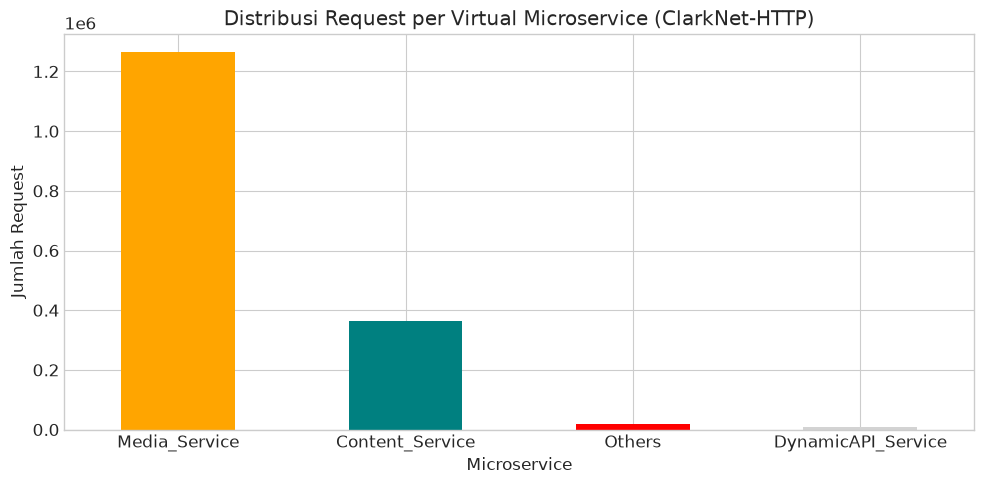

In [5]:
service_counts = df['service'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color=['orange', 'teal', 'red', 'lightgrey'])
plt.title('Distribusi Request per Virtual Microservice (ClarkNet-HTTP)')
plt.xlabel('Microservice')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resample ke 1 detik untuk menghitung total RPS (Spans 7 days, ~600k rows)
print("Menghitung total RPS per detik...")
total_rps = df.resample('1s').size()

# Hitung RPS untuk masing-masing virtual microservice
print("Menghitung RPS per-layanan...")
services = df['service'].cat.categories
rps_services = {}

for svc in services:
    svc_df = df[df['service'] == svc]
    rps_services[svc] = svc_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Gabungkan ke satu DataFrame
rps_df = pd.DataFrame(rps_services)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...
Menghitung RPS per-layanan...


,Content_Service,DynamicAPI_Service,Media_Service,Others,total_rps
datetime,,,,,
1995-08-28 00:00:34,1,0,0,0,1
1995-08-28 00:00:35,0,0,2,0,2
1995-08-28 00:00:36,1,0,1,0,2
1995-08-28 00:00:37,2,0,0,0,2
1995-08-28 00:00:38,1,0,3,0,4


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik (Selama 1 Minggu):")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik (Selama 1 Minggu):
      Content_Service  DynamicAPI_Service  Media_Service    Others  total_rps
min          0.000000            0.000000       0.000000  0.000000   0.000000
mean         0.602495            0.012214       2.090346  0.031103   2.736158
max         12.000000            3.000000      37.000000  4.000000  45.000000


Plotting tren harian (RPS rata-rata per hari) untuk 1 minggu...


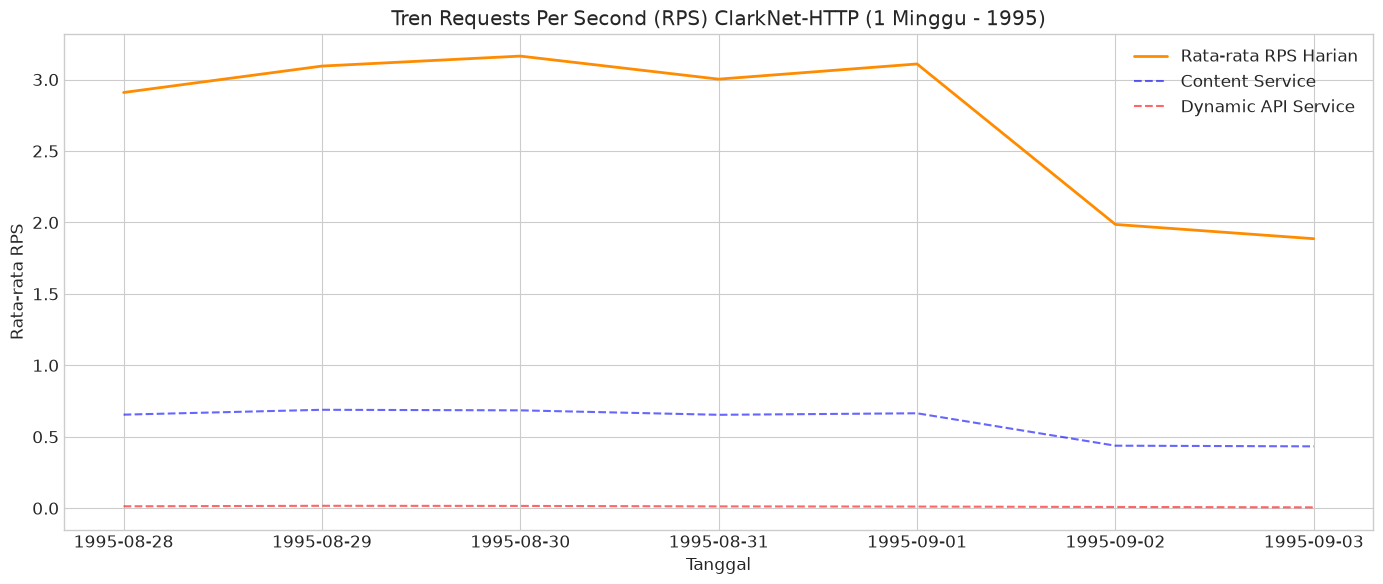

In [8]:
# Plot runtun waktu total RPS (harian agar terlihat tren mingguan)
print("Plotting tren harian (RPS rata-rata per hari) untuk 1 minggu...")
daily_rps = rps_df.resample('1D').mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_rps.index, daily_rps['total_rps'], label='Rata-rata RPS Harian', color='darkorange', linewidth=2)
plt.plot(daily_rps.index, daily_rps['Content_Service'], label='Content Service', color='blue', alpha=0.6, linestyle='--')
plt.plot(daily_rps.index, daily_rps['DynamicAPI_Service'], label='Dynamic API Service', color='red', alpha=0.6, linestyle='--')

plt.title('Tren Requests Per Second (RPS) ClarkNet-HTTP (1 Minggu - 1995)')
plt.xlabel('Tanggal')
plt.ylabel('Rata-rata RPS')
plt.legend()
plt.tight_layout()
plt.show()


Hari tersibuk: 1995-08-30


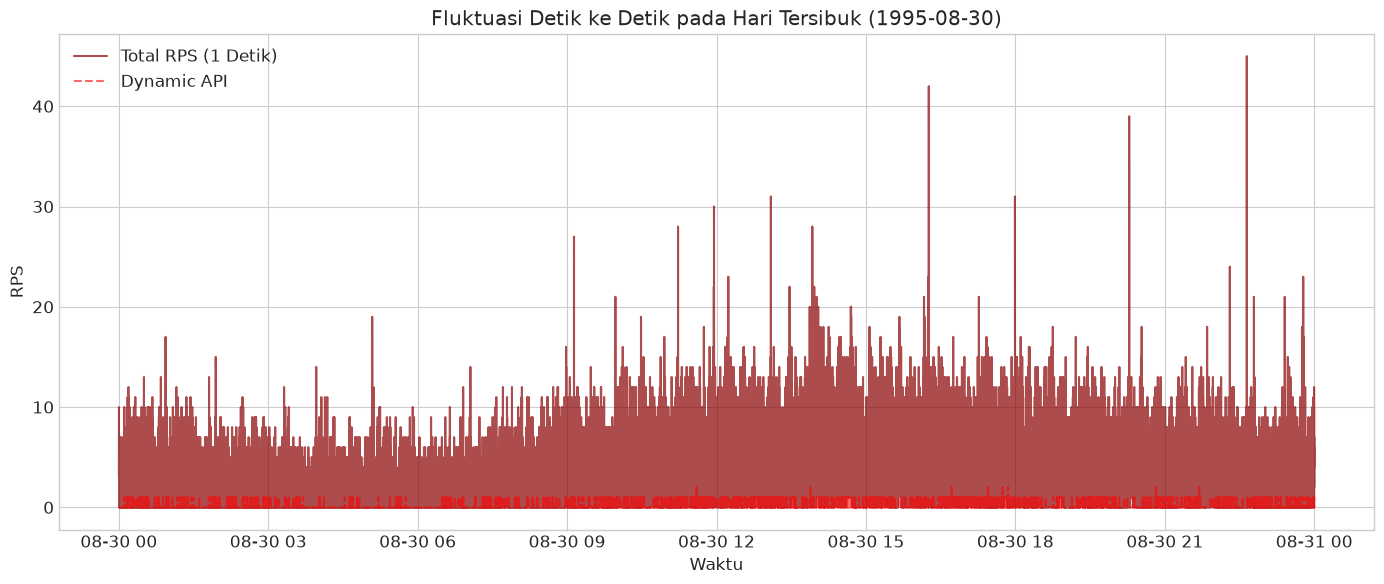

In [9]:
# Cari hari dengan trafik tersibuk di data agregasi
busy_day = rps_df['total_rps'].resample('1D').sum().idxmax()
print(f"Hari tersibuk: {busy_day.date()}")

# Zoom ke hari tersebut (24 jam)
zoomed_df = rps_df.loc[str(busy_day.date())]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (1 Detik)', color='darkred', alpha=0.7)
plt.plot(zoomed_df.index, zoomed_df['DynamicAPI_Service'], label='Dynamic API', color='red', alpha=0.6, linestyle='--')
plt.title(f'Fluktuasi Detik ke Detik pada Hari Tersibuk ({busy_day.date()})')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV
output_csv_path = 'dataset/aggregated_clarknet_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_clarknet_rps.csv


## Kesimpulan Skenario Autoscaling
Dataset **ClarkNet-HTTP** merepresentasikan beban kerja ISP regional yang sangat seimbang. Terdapat pola siklus mingguan (weekdays vs weekend) serta lonjakan harian yang jelas, menjadikannya pilihan solid untuk simulasi auto-scaling.